In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import pingouin as pg

import glob
import os
import shutil

pd.options.display.max_info_rows = 30000000
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 100)

sns.set_theme(style='darkgrid')

# Tamaño figuras
plt.rcParams["figure.figsize"] = (20,8)
plt.rcParams["figure.dpi"] = 100

pd.options.mode.chained_assignment = None

# Paleta de colores
color = ['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51', '#b13c47']

color2 = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51', '#b13c47']

color3 = ['#592B9E', '#E9C46A', '#DBA262', '#D4915E', '#CD8059', '#6FD393', '#6AC79D', '#65BAA6', '#60AEB0']

color4 = ['#34759e', '#d95b5d', '#52b179']

color5 = ['#fc8d62', '#8da0cb', '#66c2a5']

sns.set_style({'font.family': 'Arial'})

In [2]:
# Read ../results/resultados-definitivos-paper.csv
df = pd.read_csv('../../results/resultados-definitivos-paper.csv', sep=',')

In [3]:
df['algorithm'] = df['algorithm'].replace('fges', 'Fges')
df['algorithm'] = df['algorithm'].replace('fges-faithfulness', 'Fges-fa')
df['algorithm'] = df['algorithm'].replace('ges-tetrad', 'Fges-ges')
df['algorithm'] = df['algorithm'].replace('ges', 'GES')
df['algorithm'] = df['algorithm'].replace('ges-noParallel', 'GES-np')
df['algorithm'] = df['algorithm'].replace('ges parallel', 'GES')
df['algorithm'] = df['algorithm'].replace('pges', 'pGES')
df['algorithm'] = df['algorithm'].replace('pges-jc', 'pGES-jc')
df['algorithm'] = df['algorithm'].replace('pges-noParallel', 'pGES-np')
df['algorithm'] = df['algorithm'].replace('pges-jc-noParallel', 'pGES-jc-np')

df.head()

,algorithm,network,bbdd,threads,pges_threads,interleaving,seed,SHD,loglike,bdeu,deltaMM,deltaMM+,deltaMM-,iterations,time(s)
0,Fges,alarm,alarm.xbif50001246_,16,0,0,-1,7,-0.281438,-54069.673911,14.0,0.0,14.0,1,0.770
1,Fges,alarm,alarm.xbif50001246_,16,-1,-1,2,7,-0.281438,-54069.673911,14.0,0.0,14.0,1,0.786
2,Fges,alarm,alarm.xbif50001246_,1,0,0,-1,7,-0.281438,-54069.673911,14.0,0.0,14.0,1,0.807
3,Fges,alarm,alarm.xbif50001246_,1,-1,-1,2,7,-0.281438,-54069.673911,14.0,0.0,14.0,1,0.784
4,Fges,alarm,alarm.xbif50001246_,2,0,0,-1,7,-0.281438,-54069.673911,14.0,0.0,14.0,1,1.046


In [4]:
df['bdeu'] = df['bdeu'] / 5000

In [5]:
# Remove GES-np with pges_threads == 0
df = df[~((df['algorithm'] == 'GES-np') & (df['pges_threads'] == 0))]

# Remove Fges with pges_threads == 0
df = df[~((df['algorithm'] == 'Fges') & (df['pges_threads'] == 0))]

# Changue pges_threads == -1 to 1
df['pges_threads'] = df['pges_threads'].replace(-1, 1)

In [6]:
# Remove Fges-fafulness with pges_threads == 0
df = df[~((df['algorithm'] == 'Fges-fa') & (df['pges_threads'] == 0))]

df = df[~((df['algorithm'] == 'Fges-fa') & (df['pges_threads'] == 0))]

# Replace pges_threads threads in Fges, Fges-fa, GES to 1
df.loc[df['algorithm'] == 'Fges', 'pges_threads'] = 1
df.loc[df['algorithm'] == 'Fges-fa', 'pges_threads'] = 1
df.loc[df['algorithm'] == 'Fges-ges', 'pges_threads'] = 1
df.loc[df['algorithm'] == 'GES', 'pges_threads'] = 1
df.loc[df['algorithm'] == 'ges-noParallel', 'pges_threads'] = 1
df.loc[df['algorithm'] == 'ges-tetrad', 'pges_threads'] = 1

In [7]:
# Remove pGES-jc with seed = -1
df = df[~((df['algorithm'] == 'pGES-jc') & (df['seed'] == -1))]

# Remove Fges-ges with seed = -1
df = df[~((df['algorithm'] == 'Fges-ges') & (df['seed'] == -1))]

# Changue seed to 2
df['seed'] = df['seed'].replace(-1, 2)

# Remove earthquake database
df = df[df['network'] != 'earthquake']

df = df[~df['algorithm'].isin(['pGES-np', 'pGES-jc-np', 'GES-np'])]


In [8]:
# Remove algorithms with threads != 16
df16 = df[df['threads'] == 16]

df1 = df[df['threads'] == 1]

# Cargamos los datos de bnlearn

In [10]:
df_bnl = pd.read_csv('results_bnlearn.csv', sep=',')
df_bnl = df_bnl.append(pd.read_csv('results_phsl.csv', sep=','), ignore_index=True)

df_bnl = df_bnl.rename(columns={'algName': 'algorithm', 'netName': 'network', 'database': 'bbdd', 'elapsedTime(s)': 'time(s)', 'shd': 'SHD', 'dfMM_avg': 'deltaMM', 'dfMM_plus': 'deltaMM+', 'dfMM_minus': 'deltaMM-'})
df_bnl = df_bnl.drop(columns=['csv_path', 'index'])
df_bnl['iterations'] = 1

df_bnl['interleaving'] = -1
df_bnl['seed'] = 2
df_bnl['threads'] = 1
df_bnl['pges_threads'] = 1
df_bnl['loglike'] = -1

# numeric variables
df_bnl['time(s)'] = df_bnl['time(s)'].str.replace(',', '.').astype(float)
df_bnl['SHD'] = df_bnl['SHD'].astype(float)
df_bnl['deltaMM'] = df_bnl['deltaMM'].str.replace(',', '.').astype(float)
df_bnl['deltaMM+'] = df_bnl['deltaMM+'].str.replace(',', '.').astype(float)
df_bnl['deltaMM-'] = df_bnl['deltaMM-'].str.replace(',', '.').astype(float)
df_bnl['iterations'] = df_bnl['iterations'].astype(int)
df_bnl['bdeu'] = df_bnl['bdeu'].str.replace(',', '.').astype(float) / 5000

df_bnl

,algorithm,network,bbdd,time(s),SHD,deltaMM,deltaMM+,deltaMM-,iterations,bdeu,interleaving,seed,threads,pges_threads,loglike
0,chow-liu,hepar2,hepar27,0.039,99.0,340.0,10.0,330.0,1,-33.201745,-1,2,1,1,-1
1,chow-liu,hepar2,hepar28,0.041,101.0,344.0,12.0,332.0,1,-33.035930,-1,2,1,1,-1
2,chow-liu,hepar2,hepar29,0.038,97.0,336.0,8.0,328.0,1,-33.068132,-1,2,1,1,-1
3,chow-liu,alarm,alarm9,0.015,39.0,92.0,10.0,82.0,1,-12.042908,-1,2,1,1,-1
4,chow-liu,hepar2,hepar210,0.036,97.0,328.0,8.0,320.0,1,-33.098704,-1,2,1,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,ppc-path,barley,barley8,11.528,102.0,248.0,6.0,242.0,1,-67.094062,-1,2,1,1,-1
2194,ppc-path,barley,barley10,10.481,107.0,260.0,6.0,254.0,1,-67.472625,-1,2,1,1,-1
2195,ppc-path,barley,barleyAll,3.859,106.0,258.0,8.0,250.0,1,-67.169887,-1,2,1,1,-1
2196,ppc-path,child,child1,2.512,14.0,30.0,8.0,22.0,1,-13.040948,-1,2,1,1,-1


In [11]:
df_temp = pd.read_csv('results_mmhc-tetrad.csv', sep=',').append(pd.read_csv('results_pc-tetrad.csv', sep=','))
df_temp['algName'] = df_temp['algName'].replace('mmhc', 'mmhc-te')
df_temp['algName'] = df_temp['algName'].replace('pc', 'pc-te')

df_temp = df_temp.rename(columns={'algName': 'algorithm', 'netName': 'network', 'database': 'bbdd', 'elapsedTime(s)': 'time(s)', 'shd': 'SHD', 'dfMM_avg': 'deltaMM', 'dfMM_plus': 'deltaMM+', 'dfMM_minus': 'deltaMM-'})
df_temp['iterations'] = 1

df_temp['interleaving'] = -1
df_temp['seed'] = 2
df_temp['threads'] = 1
df_temp['pges_threads'] = 1
df_temp['loglike'] = -1
df_temp['bdeu'] = df_temp['bdeu'] / 5000

df_bnl = df_bnl.append(df_temp)

In [12]:
# Borrar experimentos con bbdd termiando en All
df_bnl = df_bnl[~df_bnl['bbdd'].str.endswith('All')]

In [13]:
df_joint = pd.concat([df, df_bnl])
df_joint1 = pd.concat([df1, df_bnl])
df_joint16 = pd.concat([df16, df_bnl])
df_joint

,algorithm,network,bbdd,threads,pges_threads,interleaving,seed,SHD,loglike,bdeu,deltaMM,deltaMM+,deltaMM-,iterations,time(s)
1,Fges,alarm,alarm.xbif50001246_,16,1,-1,2,7.0,-0.281438,-10.813935,14.0,0.0,14.0,1,0.786
3,Fges,alarm,alarm.xbif50001246_,1,1,-1,2,7.0,-0.281438,-10.813935,14.0,0.0,14.0,1,0.784
5,Fges,alarm,alarm.xbif50001246_,2,1,-1,2,7.0,-0.281438,-10.813935,14.0,0.0,14.0,1,0.787
7,Fges,alarm,alarm.xbif50001246_,4,1,-1,2,7.0,-0.281438,-10.813935,14.0,0.0,14.0,1,0.763
9,Fges,alarm,alarm.xbif50001246_,8,1,-1,2,7.0,-0.281438,-10.813935,14.0,0.0,14.0,1,0.836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,pc-te,win95pts,win95pts8,1,1,-1,2,147.0,-1.000000,-11.259237,316.0,40.0,40.0,1,4.606
228,pc-te,win95pts,win95pts9,1,1,-1,2,149.0,-1.000000,-11.382493,318.0,48.0,48.0,1,5.316
229,pc-te,win95pts,win95pts10,1,1,-1,2,148.0,-1.000000,-11.310895,316.0,38.0,38.0,1,4.878
231,pc-te,andes,andes1,1,1,-1,2,404.0,-1.000000,-100.133986,844.0,242.0,242.0,1,43.016


In [14]:
df_joint.algorithm.unique()

array(['Fges', 'Fges-fa', 'GES', 'Fges-ges', 'pGES', 'pGES-jc',
       'chow-liu', 'fast-iamb', 'fdr-iamb', 'gs', 'h2pc', 'hc', 'iamb',
       'inter-iamb', 'mmhc', 'pc-stable', 'rsmax2', 'tabu', 'phgs', 'ppc',
       'ppc-hgi', 'ppc-path', 'mmhc-te', 'pc-te'], dtype=object)

In [15]:
# order of algorithms by type:
order = ['chow-liu', 'iamb', 'fast-iamb', 'inter-iamb','fdr-iamb', 'gs', 'pc-te', 'pc-stable', 'ppc', 'ppc-path', 'ppc-hgi', 'phgs', 'hc', 'tabu', 'mmhc', 'mmhc-te', 'h2pc', 'rsmax2', 'Fges', 'Fges-fa', 'Fges-ges', 'GES', 'pGES', 'pGES-jc']

df_joint['algorithm'] = pd.Categorical(df_joint['algorithm'], categories=order, ordered=True)
df_joint1['algorithm'] = pd.Categorical(df_joint1['algorithm'], categories=order, ordered=True)
df_joint16['algorithm'] = pd.Categorical(df_joint16['algorithm'], categories=order, ordered=True)

# Tablas de datos

In [16]:
df_unstack = df_joint.drop(["bbdd", "interleaving", "SHD", "loglike", "bdeu", "deltaMM", "deltaMM+", "deltaMM-", "iterations", "threads", "pges_threads" , "seed"], axis=1)
df_unstack.groupby(["network", "algorithm"], observed=True).count().unstack(0)

time(s)                                                            \
network      alarm  andes barley  child diabetes hailfinder hepar2 insurance   
algorithm                                                                      
chow-liu      10.0   10.0   10.0   10.0     10.0       10.0   10.0      10.0   
iamb          10.0    7.0   10.0    9.0     10.0       10.0    5.0       9.0   
fast-iamb     10.0    7.0   10.0    9.0     10.0       10.0    7.0      10.0   
inter-iamb    10.0    7.0   10.0    6.0     10.0       10.0    5.0      10.0   
fdr-iamb      10.0   10.0   10.0    7.0     10.0       10.0    5.0      10.0   
gs            10.0    7.0   10.0   10.0     10.0        9.0    8.0      10.0   
pc-te         10.0   10.0   10.0   10.0     10.0       10.0   10.0      10.0   
pc-stable     10.0    1.0   10.0   10.0     10.0        9.0   10.0      10.0   
ppc            9.0    3.0    4.0    6.0      NaN        9.0   10.0      10.0   
ppc-path       9.0   10.0    4.0    7.0      NaN        9.0   10.0      10.0   
ppc-hgi        9.0    1.0    4.0    9.0      NaN        NaN    9.0      10.0   
phgs          10.0   10.0    8.0   10.0      NaN       10.0   10.0      10.0   
hc            10.0   10.0   10.0   10.0     10.0       10.0   10.0      10.0   
tabu          10.0   10.0   10.0   10.0     10.0       10.0   10.0      10.0   
mmhc          10.0   10.0   10.0   10.0     10.0       10.0   10.0      10.0   
mmhc-te       10.0   10.0   10.0   10.0      NaN       10.0   10.0      10.0   
h2pc          10.0   10.0   10.0   10.0     10.0       10.0   10.0      10.0   
rsmax2        10.0   10.0   10.0   10.0     10.0       10.0   10.0      10.0   
Fges          55.0   55.0   55.0   55.0     55.0       55.0   55.0      55.0   
Fges-fa       55.0   55.0   55.0   55.0     55.0       55.0   55.0      55.0   
Fges-ges      55.0   55.0   55.0   55.0     55.0       55.0   55.0      55.0   
GES           55.0   55.0   55.0   55.0     55.0       55.0   55.0      55.0   
pGES         220.0  220.0  220.0  220.0    220.0      220.0  220.0     220.0   
pGES-jc      220.0  220.0  220.0  220.0    220.0      220.0  220.0     220.0   

                                                                   
network      link mildew  munin pathfinder   pigs  water win95pts  
algorithm                                                          
chow-liu     10.0   10.0   10.0       10.0   10.0   10.0     10.0  
iamb          4.0   10.0   10.0       10.0    9.0    1.0      7.0  
fast-iamb     NaN   10.0   10.0       10.0   10.0    9.0      9.0  
inter-iamb    3.0   10.0   10.0       10.0    9.0    1.0      7.0  
fdr-iamb      7.0   10.0   10.0       10.0    9.0    4.0      8.0  
gs           10.0   10.0   10.0       10.0   10.0    8.0      9.0  
pc-te        10.0   10.0   10.0       10.0    8.0   10.0     10.0  
pc-stable    10.0   10.0   10.0       10.0   10.0   10.0      6.0  
ppc           NaN   10.0    NaN        NaN    NaN   10.0      6.0  
ppc-path      NaN   10.0    NaN        NaN    NaN   10.0      7.0  
ppc-hgi       NaN   10.0    NaN        NaN    NaN   10.0      8.0  
phgs          NaN   10.0    NaN        NaN    NaN   10.0     10.0  
hc           10.0   10.0   10.0       10.0   10.0   10.0     10.0  
tabu         10.0   10.0   10.0       10.0   10.0   10.0     10.0  
mmhc         10.0   10.0   10.0       10.0   10.0   10.0     10.0  
mmhc-te      10.0   10.0   10.0       10.0   10.0   10.0     10.0  
h2pc         10.0   10.0   10.0       10.0   10.0   10.0     10.0  
rsmax2       10.0   10.0   10.0       10.0   10.0   10.0     10.0  
Fges         55.0    NaN   55.0       55.0   55.0   55.0     55.0  
Fges-fa      55.0    NaN   55.0       55.0   55.0   55.0     55.0  
Fges-ges     55.0    NaN   55.0       55.0   55.0   55.0     55.0  
GES          55.0   55.0   55.0       55.0   55.0   55.0     55.0  
pGES        220.0  220.0  219.0      220.0  220.0  220.0    220.0  
pGES-jc     220.0  220.0  220.0      220.0  220.0  220.0    220.0

In [17]:
df_unstack = df_joint16.drop(["bbdd", "interleaving", "SHD", "loglike", "bdeu", "deltaMM", "deltaMM+", "deltaMM-", "iterations"], axis=1)
df_unstack.groupby(["network", "algorithm", "threads", "pges_threads", "seed"], observed=True).mean().unstack(0)

time(s)                          \
network                                   alarm       andes      barley   
algorithm  threads pges_threads seed                                      
chow-liu   1       1            2      0.015200    0.306700    0.027100   
iamb       1       1            2      0.181700    9.041429    0.963600   
fast-iamb  1       1            2      0.246400   11.007429    0.173400   
inter-iamb 1       1            2      0.189200    9.467286    0.738500   
fdr-iamb   1       1            2      0.544200   21.745600    1.618800   
gs         1       1            2      0.509000   37.216571    2.175000   
pc-te      1       1            2      2.310800   43.772000    5.684300   
pc-stable  1       1            2      0.543800  155.277000    0.776200   
ppc        1       1            2      3.012889   32.922667  488.349250   
ppc-path   1       1            2      2.941444   35.563700  488.844750   
ppc-hgi    1       1            2      3.058556   38.343000  489.077750   
phgs       1       1            2      3.288200   31.361800  109.936125   
hc         1       1            2      0.429300   16.546200   42.772200   
tabu       1       1            2      0.691300   21.101200   43.715000   
mmhc       1       1            2      0.236000    4.505800    0.367700   
mmhc-te    1       1            2     19.131500   76.379600   34.183500   
h2pc       1       1            2      0.866300   28.853800    2.004700   
rsmax2     1       1            2      0.207600    2.970400    0.296400   
Fges       16      1            2      0.949182    2.974909    4.699727   
Fges-fa    16      1            2      1.113455   10.404545   12.166000   
Fges-ges   16      1            2      1.858545   22.322727   21.334091   
GES        16      1            2      0.785636   19.177000    1.622364   
pGES       16      2            2      1.035545    7.278455    1.782909   
                   4            2      1.079091    5.881091    1.720727   
                   8            2      1.129818    6.143182    1.802364   
                   16           2      1.252727    7.737182    2.113727   
pGES-jc    16      2            2      1.086545    8.750182    2.129182   
                   4            2      1.116182    6.619273    1.964364   
                   8            2      1.292818    6.489455    2.801727   
                   16           2      1.426455    7.958182    1.922182   

                                                                           \
network                                   child     diabetes   hailfinder   
algorithm  threads pges_threads seed                                        
chow-liu   1       1            2      0.009300     1.785200     0.026900   
iamb       1       1            2      0.087222   173.502000     0.591700   
fast-iamb  1       1            2      0.101778     7.635300     0.441700   
inter-iamb 1       1            2      0.090500   111.048000     0.580200   
fdr-iamb   1       1            2      0.185571   253.078200     1.370300   
gs         1       1            2      0.160600   306.626500     2.932444   
pc-te      1       1            2      1.769500   416.373000     4.172600   
pc-stable  1       1            2      0.264100   773.721300     1.190889   
ppc        1       1            2     10.557333          NaN    54.341333   
ppc-path   1       1            2      9.788286          NaN    54.454444   
ppc-hgi    1       1            2      9.405778          NaN          NaN   
phgs       1       1            2     10.710700          NaN    11.657300   
hc         1       1            2      0.140300   845.351600     0.808400   
tabu       1       1            2      0.251300   858.672000     0.985700   
mmhc       1       1            2      0.133600    27.935900     0.395200   
mmhc-te    1       1            2      5.477900          NaN    32.420400   
h2pc       1       1            2      0.397400   150.776500     0.886300   
rsmax2     1       1    

In [18]:
df_temp = df_unstack.groupby(["network", "algorithm", "threads", "pges_threads", "seed"], observed=True).mean().unstack(0)

# get row of mmhc algorithm
bnlearn = df_temp.loc[('mmhc', 1, 1, 2)]
tetrad = df_temp.loc[('mmhc-te', 1, 1, 2)]

tetrad / bnlearn

         network   
time(s)  alarm          81.065678
         andes          16.951396
         barley         92.965733
         child          41.002246
         diabetes             NaN
         hailfinder     82.035425
         hepar2         22.121961
         insurance      33.592223
         link          118.602925
         mildew        143.680910
         munin         288.981836
         pathfinder     17.833912
         pigs           47.566984
         water          13.385285
         win95pts       43.387181
dtype: float64

In [19]:
bnlearn = df_temp.loc[('pc-stable', 1, 1, 2)]
tetrad = df_temp.loc[('pc-te', 1, 1, 2)]

tetrad / bnlearn

         network   
time(s)  alarm          4.249356
         andes          0.281896
         barley         7.323241
         child          6.700114
         diabetes       0.538143
         hailfinder     3.503769
         hepar2         3.771853
         insurance      4.677052
         link           0.227790
         mildew        54.536174
         munin          0.259369
         pathfinder    20.227878
         pigs          39.703968
         water          3.029588
         win95pts       1.337744
dtype: float64

In [20]:
bnlearn = df_temp.loc[('pc-stable', 1, 1, 2)]
tetrad = df_temp.loc[('ppc', 1, 1, 2)]

tetrad / bnlearn

         network   
time(s)  alarm           5.540436
         andes           0.212025
         barley        629.153891
         child          39.974757
         diabetes             NaN
         hailfinder     45.630901
         hepar2          1.646395
         insurance       6.090909
         link                 NaN
         mildew         10.734060
         munin                NaN
         pathfinder           NaN
         pigs                 NaN
         water           9.754498
         win95pts        1.379958
dtype: float64

In [21]:
df_unstack = df_joint16.drop(["bbdd", "interleaving", "SHD", "loglike", "time(s)", "deltaMM", "deltaMM+", "deltaMM-", "iterations"], axis=1)
df_unstack.groupby(["network", "algorithm", "threads", "pges_threads", "seed"], observed=True).mean().unstack(0)

bdeu                         \
network                                   alarm       andes     barley   
algorithm  threads pges_threads seed                                     
chow-liu   1       1            2    -12.013277 -103.653132 -63.485625   
iamb       1       1            2    -13.442344  -98.467011 -66.177463   
fast-iamb  1       1            2    -13.574344  -98.534824 -71.164095   
inter-iamb 1       1            2    -13.313190  -98.486409 -66.837078   
fdr-iamb   1       1            2    -13.527415  -99.379135 -67.216240   
gs         1       1            2    -16.405385 -106.328883 -76.661568   
pc-te      1       1            2    -12.367855  -98.696683 -73.779467   
pc-stable  1       1            2    -13.630697 -100.316955 -69.726887   
ppc        1       1            2    -13.155911  -98.867421 -67.250459   
ppc-path   1       1            2    -13.152335  -98.815329 -67.244915   
ppc-hgi    1       1            2    -13.152517  -96.983377 -67.250459   
phgs       1       1            2    -12.825003  -97.546510 -67.789622   
hc         1       1            2    -10.951961  -94.641632 -53.881221   
tabu       1       1            2    -10.898036  -94.570570 -53.864835   
mmhc       1       1            2    -12.703188  -97.264389 -65.812754   
mmhc-te    1       1            2    -13.246405  -96.281565 -73.221989   
h2pc       1       1            2    -12.353314  -96.959385 -63.121745   
rsmax2     1       1            2    -14.779761  -97.683874 -66.765078   
Fges       16      1            2    -10.788383  -94.740114 -53.357547   
Fges-fa    16      1            2    -10.788383  -94.523032 -52.838533   
Fges-ges   16      1            2    -10.790218  -94.520367 -52.829682   
GES        16      1            2    -10.873255  -94.316279 -53.223129   
pGES       16      2            2    -10.789202  -94.317145 -52.800118   
                   4            2    -10.787501  -94.316678 -52.959689   
                   8            2    -10.787846  -94.314761 -52.917580   
                   16           2    -10.787357  -94.315374 -53.231814   
pGES-jc    16      2            2    -10.788219  -94.316018 -52.816724   
                   4            2    -10.788722  -94.314834 -52.803980   
                   8            2    -10.788722  -94.314840 -52.820143   
                   16           2    -10.792013  -94.315887 -52.793388   

                                                                        \
network                                   child    diabetes hailfinder   
algorithm  threads pges_threads seed                                     
chow-liu   1       1            2    -12.681103 -425.876153 -51.726313   
iamb       1       1            2    -12.745516 -614.079772 -58.771974   
fast-iamb  1       1            2    -13.384900 -727.128140 -59.873207   
inter-iamb 1       1            2    -12.658175 -497.355126 -57.711259   
fdr-iamb   1       1            2    -12.751789 -498.614300 -57.732846   
gs         1       1            2    -14.331221 -711.407647 -64.219426   
pc-te      1       1            2    -13.129945 -721.669904 -62.094052   
pc-stable  1       1            2    -12.705657 -604.222904 -58.336670   
ppc        1       1            2    -13.088354         NaN -58.441765   
ppc-path   1       1            2    -13.078363         NaN -58.363601   
ppc-hgi    1       1            2    -12.964219         NaN        NaN   
phgs       1       1            2    -12.691934         NaN -58.317350   
hc         1       1            2    -12.520903 -230.799106 -50.479578   
tabu       1       1            2    -12.456497 -230.799732 -50.469270   
mmhc       1       1            2    -12.714925 -600.167233 -58.910580   
mmhc-te    1       1            2    -12.964838         NaN -60.041213   
h2pc       1       1            2    -12.619612 -528.007271 -58.402648   
rsmax2     1       1            2    -13.083507 -688.077344 -59.264878   
Fges       16      1            2    -12.45872

In [22]:
df_unstack = df_joint16.drop(["bbdd", "interleaving",  "bdeu", "loglike", "time(s)", "deltaMM", "deltaMM+", "deltaMM-", "iterations"], axis=1)
df_unstack.groupby(["network", "algorithm", "threads", "pges_threads", "seed"], observed=True).mean().unstack(0)

SHD                          \
network                                   alarm       andes      barley   
algorithm  threads pges_threads seed                                      
chow-liu   1       1            2     39.000000  429.600000  100.400000   
iamb       1       1            2     31.300000  281.000000  101.200000   
fast-iamb  1       1            2     33.000000  288.428571  104.800000   
inter-iamb 1       1            2     30.000000  280.142857  100.400000   
fdr-iamb   1       1            2     31.400000  323.600000  101.300000   
gs         1       1            2     55.700000  452.000000  117.800000   
pc-te      1       1            2     24.300000  372.900000  117.100000   
pc-stable  1       1            2     28.400000  424.000000  105.900000   
ppc        1       1            2     29.111111  360.333333  105.750000   
ppc-path   1       1            2     28.666667  331.100000  105.250000   
ppc-hgi    1       1            2     28.777778  301.000000  105.750000   
phgs       1       1            2     28.700000  247.400000  105.500000   
hc         1       1            2     23.700000  226.600000   64.800000   
tabu       1       1            2     21.300000  222.900000   64.700000   
mmhc       1       1            2     23.400000  238.500000   99.800000   
mmhc-te    1       1            2     29.100000  255.600000  115.100000   
h2pc       1       1            2     19.700000  190.800000   97.000000   
rsmax2     1       1            2     42.000000  244.200000  100.300000   
Fges       16      1            2      7.909091  232.454545   59.545455   
Fges-fa    16      1            2      7.909091  179.272727   55.909091   
Fges-ges   16      1            2      8.000000  180.000000   57.545455   
GES        16      1            2      9.272727  151.545455   61.181818   
pGES       16      2            2      8.090909  152.818182   56.000000   
                   4            2      7.545455  153.363636   57.909091   
                   8            2      7.545455  151.000000   60.454545   
                   16           2      7.272727  151.727273   60.545455   
pGES-jc    16      2            2      7.272727  152.272727   56.454545   
                   4            2      7.363636  151.181818   56.454545   
                   8            2      7.363636  151.181818   56.454545   
                   16           2      7.545455  151.909091   56.090909   

                                                                         \
network                                   child    diabetes  hailfinder   
algorithm  threads pges_threads seed                                      
chow-liu   1       1            2     11.000000  508.800000   52.400000   
iamb       1       1            2      9.444444  674.800000   61.700000   
fast-iamb  1       1            2     11.333333  788.100000   60.700000   
inter-iamb 1       1            2      8.000000  532.200000   61.100000   
fdr-iamb   1       1            2      8.857143  532.300000   62.400000   
gs         1       1            2     20.300000  769.500000  100.555556   
pc-te      1       1            2     12.200000  779.800000   81.100000   
pc-stable  1       1            2      8.500000  721.100000   59.888889   
ppc        1       1            2     12.166667         NaN   64.777778   
ppc-path   1       1            2     12.000000         NaN   61.000000   
ppc-hgi    1       1            2     11.333333         NaN         NaN   
phgs       1       1            2      7.500000         NaN   63.500000   
hc         1       1            2      2.900000  362.800000   40.000000   
tabu       1       1            2      0.600000  363.000000   40.000000   
mmhc       1       1            2      8.200000  667.100000   67.100000   
mmhc-te    1       1            2      9.400000         NaN   79.000000   
h2pc       1       1            2      3.400000  601.700000   63.400000   
rsmax2     1       1            2     12.200000  761.100000   66.000

# exreport

In [197]:
df2 = df_joint16[df_joint16['algorithm'].isin([
    'chow-liu', 'iamb', 'fast-iamb', 'inter-iamb','fdr-iamb', 'gs', 'pc-te', 'pc-stable', 'ppc', 'ppc-path', 'ppc-hgi', 'phgs', 'hc', 'tabu', 'mmhc', 'mmhc-te', 'h2pc', 'rsmax2', 
    'Fges', 
    'Fges-fa',
    #'Fges-ges',
    'GES',
    'pGES',
    'pGES-jc',
    ])]

df2 = df2.drop(["threads","seed","interleaving","iterations"], axis=1)

# Mean of all the bbdd
df2 = df2.groupby(["network", "algorithm", "pges_threads"], observed=True).mean().reset_index()

# Delete the character / from the header
df2.columns = df2.columns.str.replace('/', '')

# Redondear a 4 decimales
df2 = df2.round(4)

# Write csv 
df2.to_csv('./exreport/exreport.csv', index=False)

# Delete folder exreport_output and its content if exists
if os.path.exists('./exreport/exreport_output'):
    shutil.rmtree('./exreport/exreport_output')

In [198]:
# Execute exreport.r
os.system('Rscript ./exreport/exreport.r')

[1] "/Users/pablo/Library/CloudStorage/OneDrive-UniversidaddeCastilla-LaMancha/Documentos/6.Doctorado/ParallelBNs/notebooks/Experimentos review bnlearn/exreport"
'data.frame':	385 obs. of  10 variables:
 $ network     : Factor w/ 15 levels "alarm","andes",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ algorithm   : Factor w/ 23 levels "Fges","Fges-fa",..: 4 10 5 11 6 7 17 16 19 21 ...
 $ pges_threads: int  1 1 1 1 1 1 1 1 1 1 ...
 $ SHD         : num  39 31.6 33.7 29.8 30.8 ...
 $ loglike     : num  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 ...
 $ bdeu        : num  -12 -13.5 -13.6 -13.4 -13.5 ...
 $ deltaMM     : num  92 74.9 78.3 69 72 ...
 $ deltaMM.    : num  10 6.86 6.57 6.25 5.6 ...
 $ deltaMM..1  : num  82 68 71.7 62.8 66.4 ...
 $ time.s.     : num  0.0152 0.1799 0.2476 0.1894 0.5436 ...
1 ) Experiment pGES loaded from a data set.

#Experiment name: pGES

#algorithm: Fges, Fges-fa, GES, chow-liu, fast-iamb, fdr-iamb, gs, h2pc, hc, iamb, inter-iamb, mmhc, mmhc-te, pGES, pGES-jc, pc-stable, pc-te, phgs, ppc,

Warning message:
The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the exreport package.
  Please report the issue to the authors. 


[1] "Distribution of ranks for output \"bdeu\""
---------------------------------------------------------------------
Friedman test, objetive minimize output variable SHD. Obtained p-value: 1.1777e-37
Chi squared with 28 degrees of freedom statistic: 250.7954
Test rejected: p-value: 1.1777e-37 < 0.0500
---------------------------------------------------------------------
Control post hoc test for output SHD
Adjust method: Holm

Control method: pGES-jc,2
p-values:
          GES,1	1.0000
         pGES,2	1.0000
         pGES,4	1.0000
      pGES-jc,4	1.0000
         pGES,8	1.0000
      pGES-jc,8	1.0000
        pGES,16	1.0000
     pGES-jc,16	1.0000
      Fges-fa,1	0.3248
           hc,1	0.3248
         tabu,1	0.3248
         Fges,1	0.0987
         h2pc,1	0.0987
         mmhc,1	0.0064
     chow-liu,1	0.0014
     fdr-iamb,1	0.0010
   inter-iamb,1	0.0008
         iamb,1	0.0005
    pc-stable,1	0.0001
       rsmax2,1	0.0001
      mmhc-te,1	0.0001
    fast-iamb,1	0.0000
         phgs,1	0.0000
   

Fontconfig warning: ignoring UTF-8: not a valid region tag


0

# Gráficas

In [231]:
ruta = 'figures/'
os.makedirs(ruta, exist_ok=True)
x_order=['child', 'insurance', 'water', 'mildew', 'alarm', 'barley', 'hailfinder', 'hepar2', 'win95pts', 'pathfinder', 'andes', 'diabetes', 'pigs', 'link', 'munin']

# Rename ppc to pPC, phgs to pHGS, mmhc to MMHC and h2pc to H2PC
df_joint16['algorithm'] = df_joint16['algorithm'].replace('ppc', 'pPC')
df_joint16['algorithm'] = df_joint16['algorithm'].replace('phgs', 'pHGS')
df_joint16['algorithm'] = df_joint16['algorithm'].replace('mmhc', 'MMHC')
df_joint16['algorithm'] = df_joint16['algorithm'].replace('h2pc', 'H2PC')

df_joint16['algorithm'] = df_joint16['algorithm'].replace('pc-stable', 'PC-Stable')
#df_joint16['algorithm'] = df_joint16['algorithm'].replace('pc-te', 'PC')
df_joint16['algorithm'] = df_joint16['algorithm'].replace('hc', 'HC')

order2 = ['PC-Stable', 'pPC','pHGS', 'MMHC', 'H2PC', 'HC', 'GES']

# Only mantain algoritms: pc-tetrad, pc-stable, mmhc, mmhc-tetrad, tabu, hc, h2pc, GES, pGES, pGES-jc
df_joint2 = df_joint16[df_joint16['algorithm'].isin(order2)]
df_joint2 = df_joint2.groupby(["network", "algorithm", "pges_threads"], observed=True).mean().reset_index()

df_joint2['algorithm'] = pd.Categorical(df_joint2['algorithm'], categories=order2, ordered=True)

In [232]:
custom_palette = ["#0B2447", "#19376D",  #'pc-te', 'pc-stable'
                  "#A1EEBD", "#74E291", "#0D9276",  #'mmhc', 'mmhc-te', 'h2pc',
                  "#F5DD61", "#F4A261",  #'hc', 'tabu'
                  "#BF3131", "#7D0A0A",  #'Fges', 'Fges-fa',
                  "#C683D7", "#FF90C2", "#ED5AB3"  #'GES', 'pGES', 'pGES-jc'
                  ]
sns.color_palette(custom_palette)

[(0.043137254901960784, 0.1411764705882353, 0.2784313725490196),
 (0.09803921568627451, 0.21568627450980393, 0.42745098039215684),
 (0.6313725490196078, 0.9333333333333333, 0.7411764705882353),
 (0.4549019607843137, 0.8862745098039215, 0.5686274509803921),
 (0.050980392156862744, 0.5725490196078431, 0.4627450980392157),
 (0.9607843137254902, 0.8666666666666667, 0.3803921568627451),
 (0.9568627450980393, 0.6352941176470588, 0.3803921568627451),
 (0.7490196078431373, 0.19215686274509805, 0.19215686274509805),
 (0.49019607843137253, 0.0392156862745098, 0.0392156862745098),
 (0.7764705882352941, 0.5137254901960784, 0.8431372549019608),
 (1.0, 0.5647058823529412, 0.7607843137254902),
 (0.9294117647058824, 0.35294117647058826, 0.7019607843137254)]

In [233]:
custom_palette = ["#2B4467",  #'ppc
                  "#8da0cb",  #'phgs
                  "#369275", "#66c2a5",  #'mmhc', 'h2pc',
                  "#fc8d62",   #'ges',
                  ]
sns.color_palette(custom_palette)

[(0.16862745098039217, 0.26666666666666666, 0.403921568627451),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.21176470588235294, 0.5725490196078431, 0.4588235294117647),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

In [234]:
custom_palette = ["#2B4467",  # pc-stable
                  "#8da0cb",  #'ppc
                  "#31856A",  #'phgs
                  "#4EAA8D", "#74C8AD",  #'mmhc', 'h2pc',
                  "#fc8d62",   #'hc'
                  "#ac5d62",   #'ges',
                  ]
sns.color_palette(custom_palette)

[(0.16862745098039217, 0.26666666666666666, 0.403921568627451),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.19215686274509805, 0.5215686274509804, 0.41568627450980394),
 (0.3058823529411765, 0.6666666666666666, 0.5529411764705883),
 (0.4549019607843137, 0.7843137254901961, 0.6784313725490196),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.6745098039215687, 0.36470588235294116, 0.3843137254901961)]

In [288]:
def plotBar(df, variable, title):

    col_wrap = 5

    # Plot variable vs iterations for each network
    g = sns.catplot(data=df, x='algorithm', y=variable, kind='bar', col='network', ci=None, col_wrap=col_wrap, height=2.5, aspect=1, col_order=x_order, sharex=False, sharey=False, palette=custom_palette)
    g.set_xticklabels(rotation=60)

    for ax in g.axes:
        ax.tick_params(axis='y', which='major', pad=-2)
        ax.tick_params(axis='x', which='major', pad=-4)

    # Set axis labels
    g.set_axis_labels("Algorithm", title)

    i = 0
    # verical line in x=5000 and x=55000
    for ax in g.axes:
        ax.set_title('$\\bf{Network:}$ ' + x_order[i])

        if i % col_wrap == 0:
            ax.set_ylabel(title, weight='bold')

        if i >= col_wrap * 2:
            ax.set_xlabel('Algorithm', weight='bold')
        
        i = i+1


    NUM_ALGORITHMS = 7
    for ax in g.axes:
        df_temp2 = df[df['network'] == ax.get_title().split(' ')[1].strip()]
        # Drop 

        nan_idx = np.where(df_temp2.groupby(['algorithm']).mean().isnull()['SHD'])[0]

        for i in nan_idx:
            x_value = int(i/NUM_ALGORITHMS)    # x_value es 0, 1 o 2 para nClients 5, 10 o 20 respectivamente
            # Cada j tiene un ancho de 0.8. Por lo que cada barra tiene un ancho de 0.8/7, 0.1142857142857143
            # Por tanto, hay que hacer el módulo de i%7 y multiplicarlo por 0.8/7
            tam = 7/NUM_ALGORITHMS
            desp = (i%NUM_ALGORITHMS)*tam
            ax.axvspan(x_value - 0.5 + desp + 0.1, x_value - 0.5 + desp + tam - 0.1, facecolor='grey', alpha=0.3, hatch='X')


    # Set title
    #g.fig.suptitle(title, y=1.02)
        
    #g.fig.subplots_adjust (wspace=.25, hspace=.5)
    g.fig.subplots_adjust (wspace=.25, hspace=.6)

    g.savefig(ruta + 'comparacion_' + variable + '.pdf')

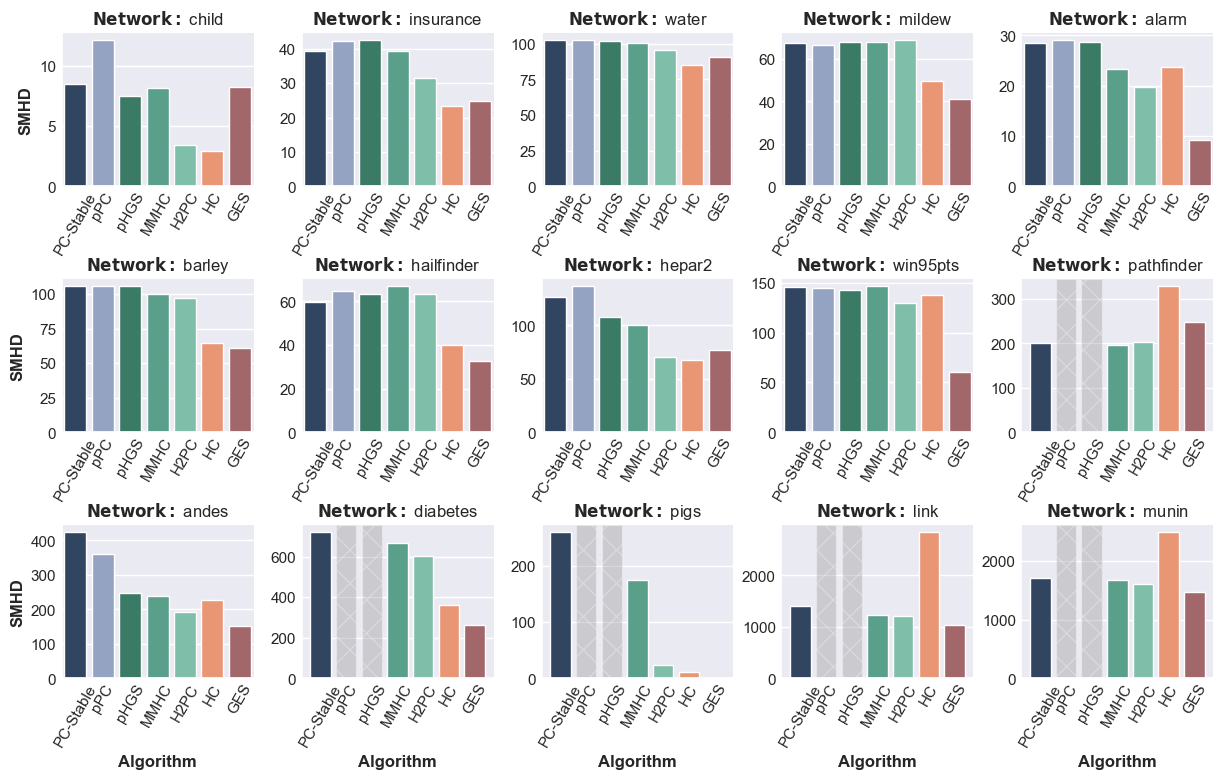

In [289]:
plotBar(df_joint2, 'SHD', 'SMHD')

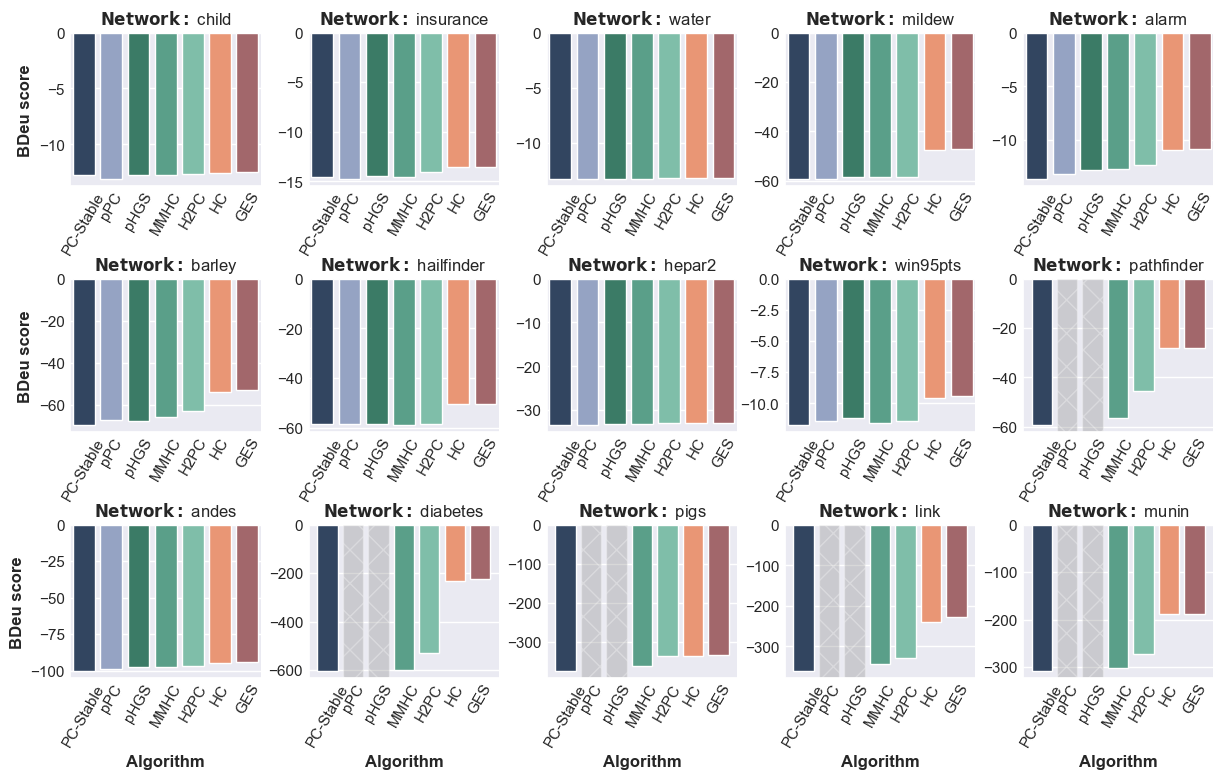

In [290]:
plotBar(df_joint2, 'bdeu', 'BDeu score')

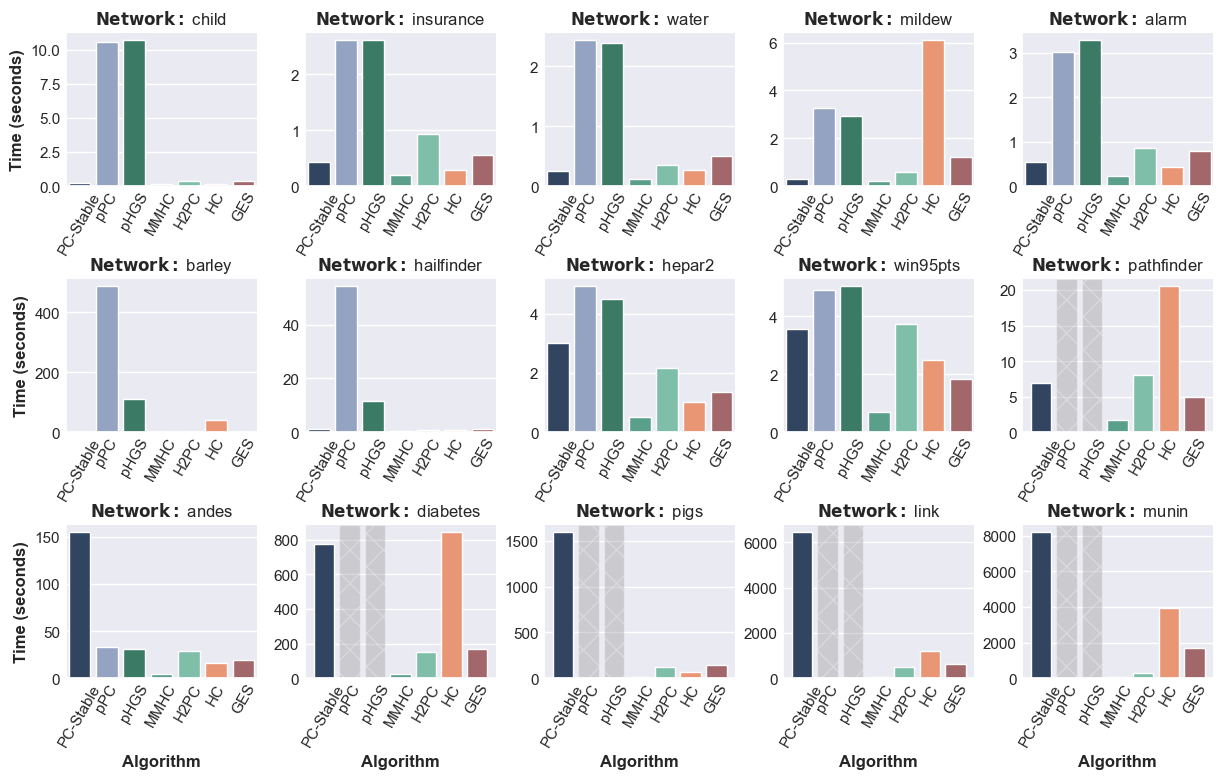

In [291]:
plotBar(df_joint2, 'time(s)', 'Time (seconds)')

# Gráfica evolución por número de instancias

In [239]:
# Read results_large_databases.csv
df_large = pd.read_csv('results_large_databases_pGES-GES.csv', sep=',')
df_large = df_large.append(pd.read_csv('results_large_databases_pGES-noJoin.csv', sep=','), ignore_index=True)
df_large = df_large.rename(columns={'algName': 'algorithm', 'numberOfRealThreads' : 'pgesThreads', 'netName': 'network', 'database': 'bbdd', 'elapsedTime(s)': 'time(s)', 'shd': 'SHD', 'dfMM_avg': 'deltaMM', 'dfMM_plus': 'deltaMM+', 'dfMM_minus': 'deltaMM-'})

# change pgesThreads in GES to 1
df_large.loc[df_large['algorithm'] == 'ges', 'pgesThreads'] = 1

df_large['algorithm'] = df_large['algorithm'].replace('ges', 'GES')
df_large['algorithm'] = df_large['algorithm'].replace('pges', 'pGES_B')
df_large['algorithm'] = df_large['algorithm'].replace('pges-nojoint', 'pGES')

df_large['instances'] = df_large['bbdd'].str.split('_').str[1].astype(int)
df_large = df_large.drop(columns=['bbdd'])

df_large['bdeu'] = df_large['bdeu'] / df_large['instances']

# order by network, pgesThreads
df_large = df_large.sort_values(by=['network', 'instances', 'pgesThreads'])

df_large.head()

,algorithm,pgesThreads,network,time(s),SHD,deltaMM,deltaMM+,deltaMM-,iterations,bdeu,instances
172,GES,1,andes,16.640,252.0,532.0,2.0,2.0,1.0,-97.353167,1000
173,GES,1,andes,16.656,252.0,532.0,2.0,2.0,1.0,-97.353167,1000
174,GES,1,andes,16.763,252.0,532.0,2.0,2.0,1.0,-97.353167,1000
175,GES,1,andes,16.656,252.0,532.0,2.0,2.0,1.0,-97.353167,1000
367,pGES_B,2,andes,7.170,245.0,518.0,8.0,8.0,6.0,-97.236303,1000


He cambiado esta línea, tiene que estar mal:

pges,16,diabetes,diabetes_50000,342.63,249.0,546.0,360.0,360.0,9.0,-9866134.26071241

In [240]:
# see values of ges with pigs
df_large[(df_large['network'] == 'pigs') & (df_large['algorithm'] == 'GES')].groupby(['instances']).mean()

,pgesThreads,time(s),SHD,deltaMM,deltaMM+,deltaMM-,iterations,bdeu
instances,,,,,,,,
1000,1.0,142.78400,0.0,0.0,0.0,0.0,1.0,-346.724155
2000,1.0,142.47275,0.0,0.0,0.0,0.0,1.0,-339.399090
5000,1.0,144.15050,0.0,0.0,0.0,0.0,1.0,-334.995750
10000,1.0,152.78650,0.0,0.0,0.0,0.0,1.0,-333.345054
20000,1.0,142.34575,0.0,0.0,0.0,0.0,1.0,-43.241239
50000,1.0,160.92700,0.0,0.0,0.0,0.0,1.0,-331.646135
100000,1.0,174.10750,0.0,0.0,0.0,0.0,1.0,-331.440934
200000,1.0,147.69275,0.0,0.0,0.0,0.0,1.0,-19.513067


In [241]:
# see values of ges with pigs
df_large[(df_large['network'] == 'pigs') & (df_large['algorithm'] == 'pGES')]

,algorithm,pgesThreads,network,time(s),SHD,deltaMM,deltaMM+,deltaMM-,iterations,bdeu,instances
536,pGES,2,pigs,38.333,0.0,0.0,0.0,0.0,3.0,-346.724155,1000
535,pGES,4,pigs,20.024,0.0,0.0,0.0,0.0,3.0,-346.724155,1000
534,pGES,8,pigs,15.330,0.0,0.0,0.0,0.0,3.0,-346.724155,1000
533,pGES,16,pigs,16.449,0.0,0.0,0.0,0.0,3.0,-346.724155,1000
541,pGES,2,pigs,36.691,0.0,0.0,0.0,0.0,3.0,-339.399090,2000
540,pGES,4,pigs,22.392,0.0,0.0,0.0,0.0,3.0,-339.399090,2000
538,pGES,8,pigs,16.124,0.0,0.0,0.0,0.0,3.0,-339.399090,2000
537,pGES,16,pigs,17.010,0.0,0.0,0.0,0.0,3.0,-339.399090,2000
545,pGES,2,pigs,46.225,0.0,0.0,0.0,0.0,3.0,-334.995750,5000
544,pGES,4,pigs,28.175,0.0,0.0,0.0,0.0,4.0,-334.995750,5000


In [242]:
df_large[(df_large['network'] == 'pigs') & (df_large['algorithm'] == 'pGES_B')]

,algorithm,pgesThreads,network,time(s),SHD,deltaMM,deltaMM+,deltaMM-,iterations,bdeu,instances
212,pGES_B,2,pigs,60.436,0.0,0.0,0.0,0.0,4.0,-346.724155,1000
211,pGES_B,4,pigs,35.647,0.0,0.0,0.0,0.0,3.0,-346.724155,1000
210,pGES_B,8,pigs,23.127,0.0,0.0,0.0,0.0,4.0,-346.724155,1000
208,pGES_B,16,pigs,25.875,0.0,0.0,0.0,0.0,4.0,-346.724155,1000
216,pGES_B,2,pigs,68.702,0.0,0.0,0.0,0.0,4.0,-339.399090,2000
215,pGES_B,4,pigs,32.402,0.0,0.0,0.0,0.0,4.0,-339.399090,2000
214,pGES_B,8,pigs,23.555,0.0,0.0,0.0,0.0,4.0,-339.399090,2000
213,pGES_B,16,pigs,26.263,0.0,0.0,0.0,0.0,4.0,-339.399090,2000
221,pGES_B,2,pigs,78.261,0.0,0.0,0.0,0.0,3.0,-334.995750,5000
219,pGES_B,4,pigs,55.101,0.0,0.0,0.0,0.0,3.0,-334.995750,5000


In [250]:
# Replace bdeu values of pigs with 20000 instances to -333.0246216
df_large.loc[(df_large['network'] == 'pigs') & (df_large['instances'] == 20000), 'bdeu'] = -332.8246216

# Replace bdeu values of pigs with 200000 instances to -331.3
df_large.loc[(df_large['network'] == 'pigs') & (df_large['instances'] == 200000), 'bdeu'] = -331.3


df_large.loc[(df_large['network'] == 'pigs') & (df_large['instances'] == 20000), 'time(s)'] = (df_large.loc[(df_large['network'] == 'pigs') & (df_large['instances'] == 10000), 'time(s)'].to_numpy() + df_large.loc[(df_large['network'] == 'pigs') & (df_large['instances'] == 50000), 'time(s)'].to_numpy()) / 2

In [252]:
color5 = ['#fc8d62', '#8da0cb', '#66c2a5']
sns.color_palette(color5)

[(0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.4, 0.7607843137254902, 0.6470588235294118)]

In [253]:
x_order2 = ['pathfinder', 'andes', 'diabetes', 'pigs', 'link', 'munin']

palette_evolucion = ["#fc8d62",   # GES
                     "#8DA0CB", "#768AB7", "#5F73A2", "#314678",  # pGES 2, 4, 8, 16
                     ]
sns.color_palette(palette_evolucion)

[(0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.4627450980392157, 0.5411764705882353, 0.7176470588235294),
 (0.37254901960784315, 0.45098039215686275, 0.6352941176470588),
 (0.19215686274509805, 0.27450980392156865, 0.47058823529411764)]

In [254]:
# rename time(s) to Time (s), pgesThreads to nClusters, instances to Instances, network to Network
df_large2 = df_large.rename(columns={'time(s)': 'Time (seconds)', 'algorithm' : 'Algorithm', 'SHD': 'SMHD', 'bdeu': 'BDeu score', 'pgesThreads': '#Clusters', 'instances': 'Instances', 'network': 'Network'})

# Variable order: GES, pGES, pGES_B
df_large2['Algorithm'] = pd.Categorical(df_large2['Algorithm'], categories=['GES', 'pGES', 'pGES_B'], ordered=True)

# Delete 200000 instances
df_large2 = df_large2[df_large2['Instances'] != 200000]

In [255]:
def plot_evolucion(variable,title):

    # ci=None, style='#Clusters', 
    g = sns.relplot(data=df_large2, x='Instances', y=variable, kind='line', hue='Algorithm', col='Network', markers='o', col_wrap=3, height=2.8, aspect=1.2, facet_kws={'sharey': False, 'sharex': False}, palette=color5, col_order=x_order2)

    # Legend
    g._legend.set_title("Algorithm", prop={'weight': 'bold'})

    # Rename algorithms in the legend
    for t, l in zip(g._legend.texts, ['GES', 'pGES', 'pGES$_B$']):
        t.set_text(l)

    i = 0
    # verical line in x=5000 and x=55000
    for ax in g.axes:
        ax.axvline(x=5000, color='black', linestyle='--', linewidth=0.7, alpha=0.5, zorder=0)
        ax.axvline(x=50000, color='black', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

        ax.set_title('$\\bf{Network: }$' + x_order2[i], fontsize=11)

        if i == 0 or i == 3:
            ax.set_ylabel(variable, weight='bold')

        if i == 3 or i == 4 or i == 5:
            ax.set_xlabel('Instances', weight='bold')
        
        i = i+1


    # Logaritmic x axis
    g.set(xscale="log")

    ruta_final = ruta + 'evolutionInstances' + title + '.pdf'
    g.savefig(ruta_final)

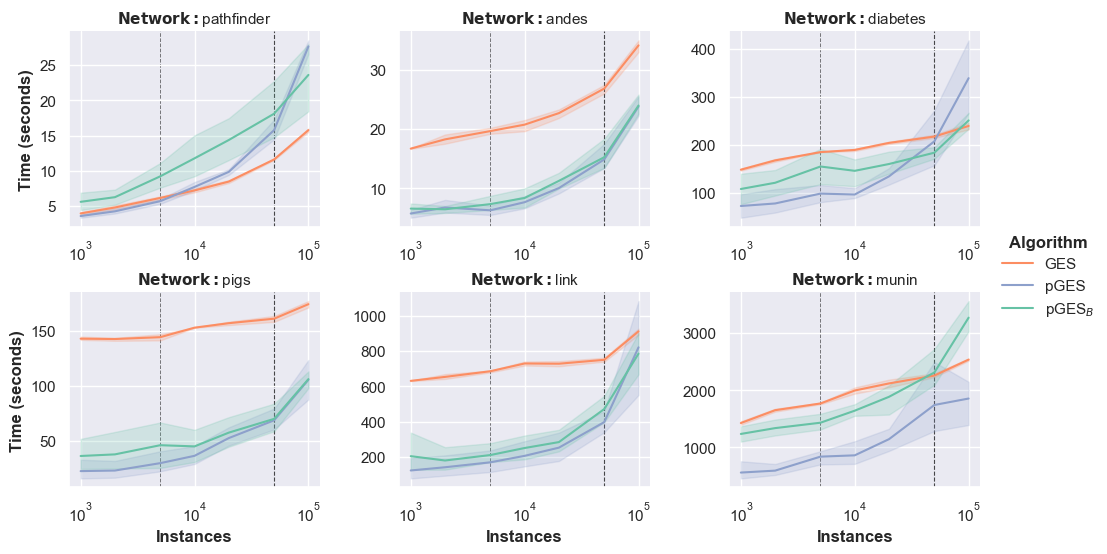

In [256]:
plot_evolucion('Time (seconds)','time')

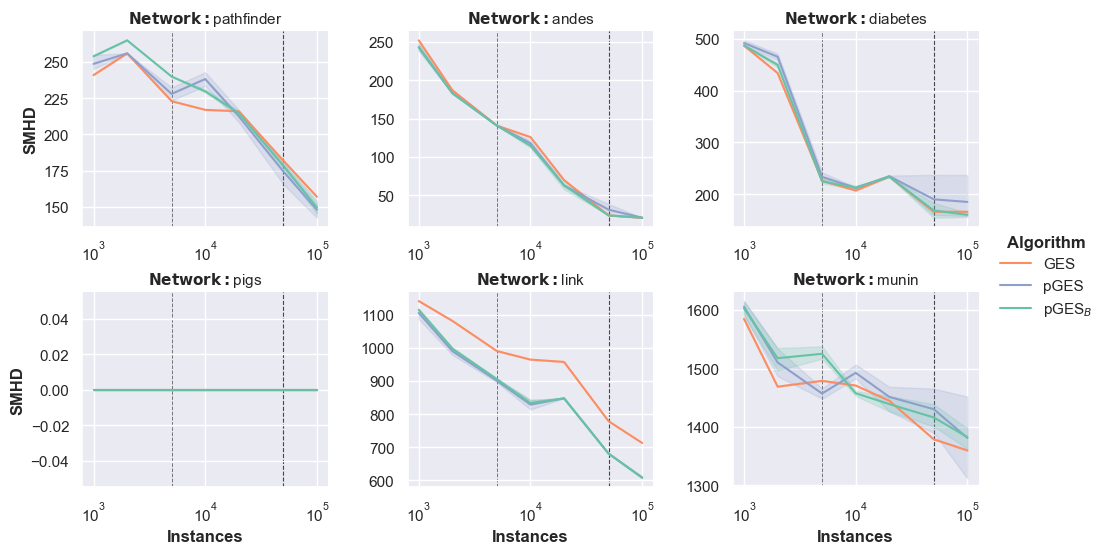

In [257]:
plot_evolucion('SMHD','SMHD')

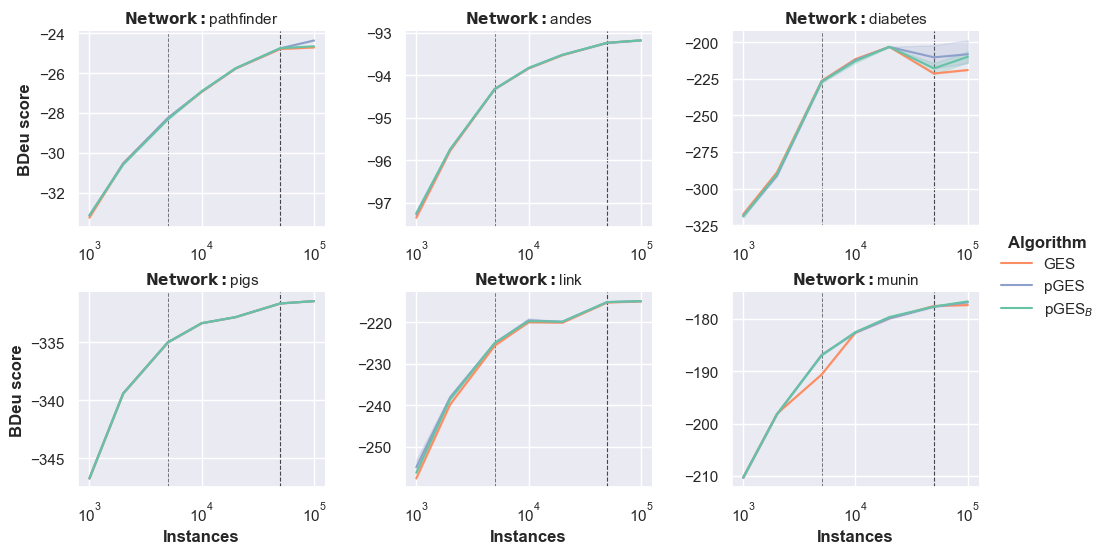

In [258]:
plot_evolucion('BDeu score','bdeu')

In [ ]:
df_large.head()

,algorithm,pgesThreads,network,time(s),SHD,deltaMM,deltaMM+,deltaMM-,iterations,bdeu,instances
172,GES,1,andes,16.640,252.0,532.0,2.0,2.0,1.0,-97.353167,1000
173,GES,1,andes,16.656,252.0,532.0,2.0,2.0,1.0,-97.353167,1000
174,GES,1,andes,16.763,252.0,532.0,2.0,2.0,1.0,-97.353167,1000
175,GES,1,andes,16.656,252.0,532.0,2.0,2.0,1.0,-97.353167,1000
367,pGES,2,andes,7.170,245.0,518.0,8.0,8.0,6.0,-97.236303,1000
